In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve, KFold
from sklearn.preprocessing import OrdinalEncoder
from imblearn.combine import SMOTETomek
from sklearn.metrics import recall_score, f1_score, precision_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [3]:
data_path = "ai-impact-jobs-layoff-risk-dataset.csv"

df = pd.read_csv(data_path)

df.head(10)

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium
5,45,PhD,9,Telecom,Network Engineer,Large,Entry,72,33,54,Medium,4,5,69,9,High
6,48,Bachelor's,10,IT,Software Engineer,Small,Entry,46,63,63,Medium,2,7,45,9,Medium
7,23,Master's,2,Retail,Store Manager,Medium,Mid,36,37,77,Low,2,0,27,3,Medium
8,24,Bachelor's,3,IT,ML Engineer,Large,Entry,41,62,90,Low,1,1,20,8,Low
9,48,Master's,6,Retail,Inventory Analyst,Small,Senior,84,8,81,Medium,2,5,67,29,Medium


In [4]:
# Getting missing values
print(df.isnull().sum())

Age                           0
Education_Level               0
Years_of_Experience           0
Industry                      0
Job_Role                      0
Company_Size                  0
Job_Level                     0
Routine_Task_Percentage       0
Creativity_Requirement        0
Human_Interaction_Level       0
AI_Adoption_Level             0
Number_of_AI_Tools_Used       0
AI_Usage_Hours_Per_Week       0
Tasks_Automated_Percentage    0
AI_Training_Hours             0
Layoff_Risk                   0
dtype: int64


In [5]:
# Checking data types of feature

print("Reading the data types : \n", df.dtypes)

Reading the data types : 
 Age                           int64
Education_Level                 str
Years_of_Experience           int64
Industry                        str
Job_Role                        str
Company_Size                    str
Job_Level                       str
Routine_Task_Percentage       int64
Creativity_Requirement        int64
Human_Interaction_Level       int64
AI_Adoption_Level               str
Number_of_AI_Tools_Used       int64
AI_Usage_Hours_Per_Week       int64
Tasks_Automated_Percentage    int64
AI_Training_Hours             int64
Layoff_Risk                     str
dtype: object


In [6]:
# Reading for unique values of object or str feature
cols = ['Education_Level', 'Industry', 'Job_Role', 'Company_Size', 'Job_Level', 'AI_Adoption_Level', 'Layoff_Risk']

for i, col_name in enumerate(cols):
    unique_count = df[col_name].unique()
    print(f"Index {i}: '{col_name}' has {unique_count} unique values")

Index 0: 'Education_Level' has <StringArray>
['Master's', 'Bachelor's', 'High School', 'PhD']
Length: 4, dtype: str unique values
Index 1: 'Industry' has <StringArray>
[      'Finance', 'Manufacturing',        'Retail',       'Telecom',
            'IT',     'Logistics',    'Healthcare',     'Education']
Length: 8, dtype: str unique values
Index 2: 'Job_Role' has <StringArray>
[           'Accountant', 'Production Supervisor',         'Store Manager',
               'Auditor',      'Network Engineer',     'Software Engineer',
           'ML Engineer',     'Inventory Analyst',            'Dispatcher',
        'Health Analyst',    'Support Specialist',       'Sales Associate',
  'Academic Coordinator',     'Financial Analyst',              'Operator',
    'Research Assistant',      'Quality Engineer',               'Teacher',
     'Warehouse Manager',  'Supply Chain Analyst',    'Operations Analyst',
     'Medical Assistant',                 'Nurse',          'Data Analyst']
Length: 24, 

In [7]:
# Encoding step to change feature into indexes

dfe = df.copy( )

ordinal_configs = {
    'Education_Level':  ['High School', "Bachelor's", "Master's", 'PhD'],
    'Company_Size':     ['Small', 'Medium', 'Large'],
    'Job_Level':        ['Entry', 'Mid', 'Senior'],
    'AI_Adoption_Level':['Low', 'Medium', 'High'],
}

for col, order in ordinal_configs.items():
    enc = OrdinalEncoder(categories=[order])
    dfe[col] = enc.fit_transform(dfe[[col]])

dfe = pd.get_dummies(dfe, columns=['Industry', 'Job_Role'], drop_first=False)

dfe['Layoff_Risk'] = dfe['Layoff_Risk'].map({"Low" : 0, "Medium" : 1, "High" : 2})

In [8]:
dfe.dtypes

Age                                 int64
Education_Level                   float64
Years_of_Experience                 int64
Company_Size                      float64
Job_Level                         float64
Routine_Task_Percentage             int64
Creativity_Requirement              int64
Human_Interaction_Level             int64
AI_Adoption_Level                 float64
Number_of_AI_Tools_Used             int64
AI_Usage_Hours_Per_Week             int64
Tasks_Automated_Percentage          int64
AI_Training_Hours                   int64
Layoff_Risk                         int64
Industry_Education                   bool
Industry_Finance                     bool
Industry_Healthcare                  bool
Industry_IT                          bool
Industry_Logistics                   bool
Industry_Manufacturing               bool
Industry_Retail                      bool
Industry_Telecom                     bool
Job_Role_Academic Coordinator        bool
Job_Role_Accountant               

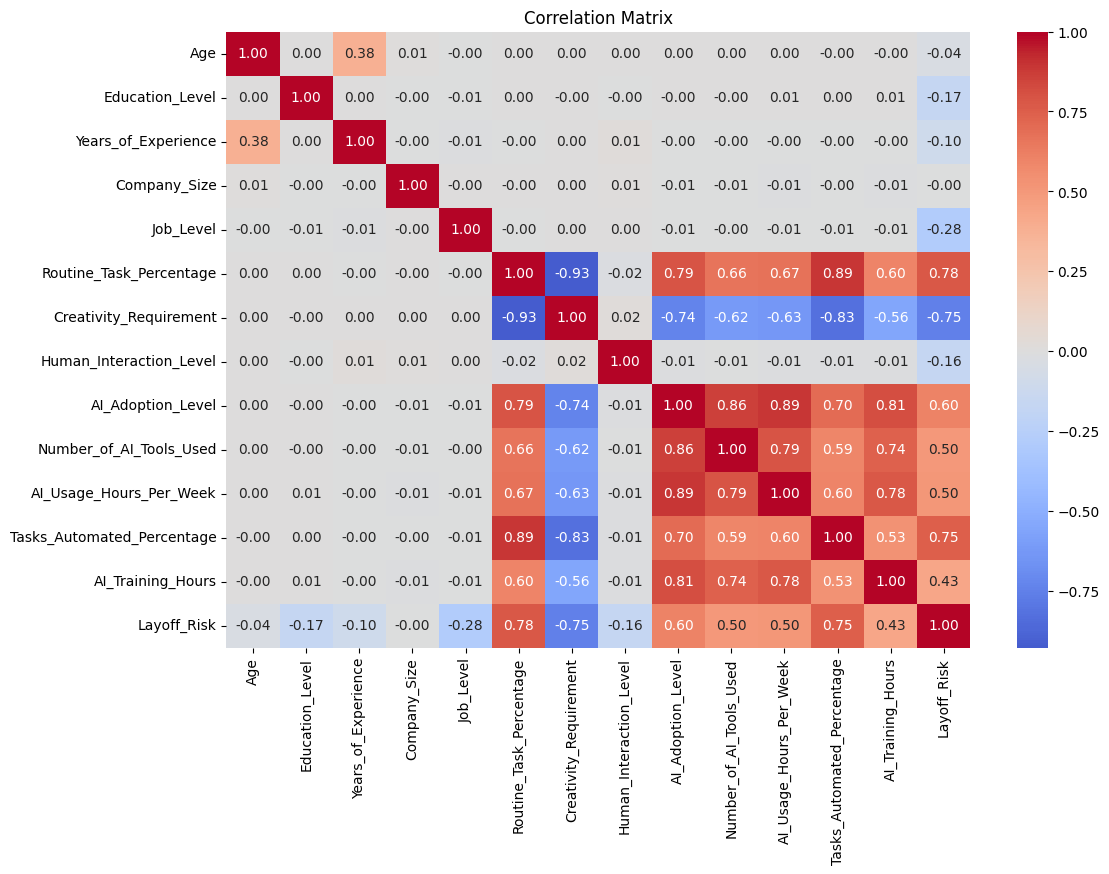

In [9]:
# EDA to visualization best of feature
corr = dfe.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

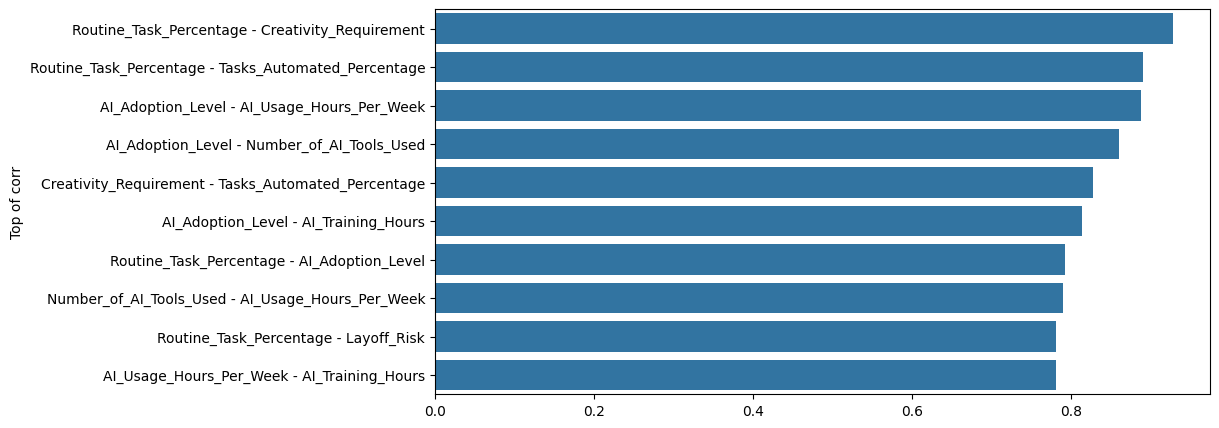

In [10]:
# Feature comparison visual data

corr_matrix = dfe.corr().abs()
corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack().sort_values(ascending=False)

top_corr = corr_pairs.head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_corr.values, y=[f"{a} - {b}" for a,b in top_corr.index])
plt.ylabel("Top of corr")

plt.show()


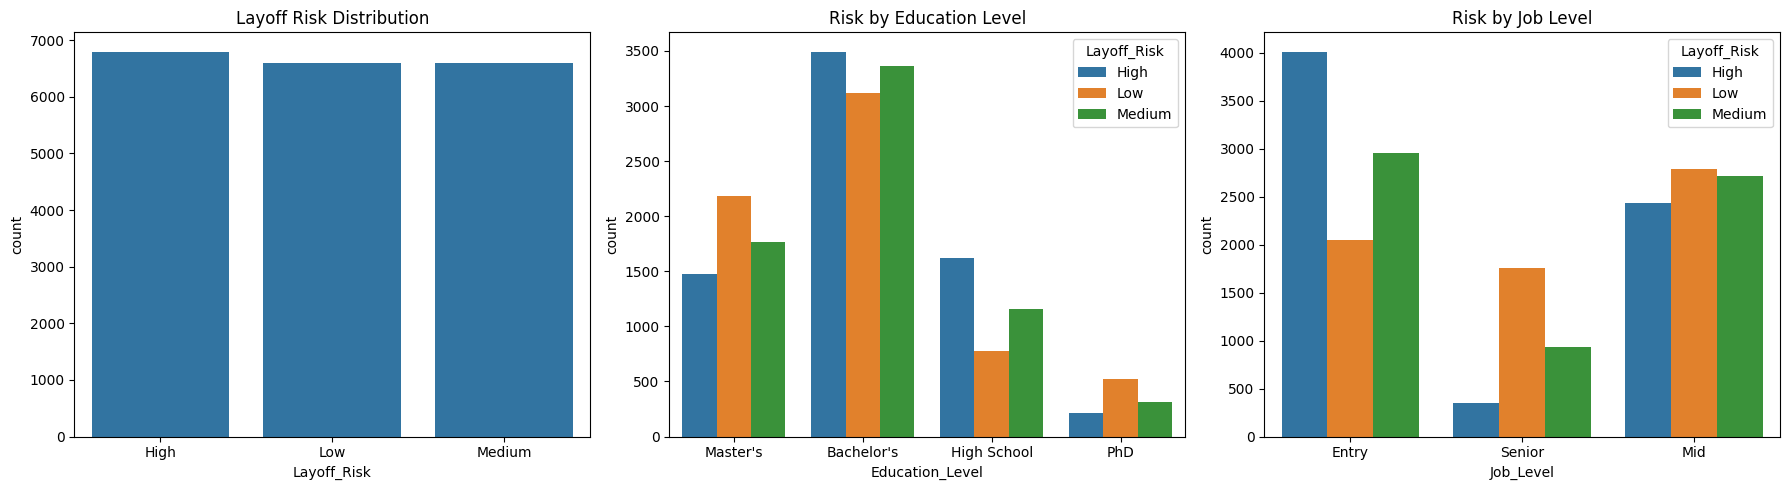

In [11]:
# EDA visualization for layoff risk 

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='Layoff_Risk', data=df, ax=axes[0])
axes[0].set_title('Layoff Risk Distribution')

sns.countplot(x='Education_Level', hue='Layoff_Risk', data=df, ax=axes[1])
axes[1].set_title('Risk by Education Level')

sns.countplot(x='Job_Level', hue='Layoff_Risk', data=df, ax=axes[2])
axes[2].set_title('Risk by Job Level')

plt.tight_layout()
plt.show()


In [12]:
X = dfe.drop(['Layoff_Risk'], axis=1)

y = dfe['Layoff_Risk']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=4, )

print("X Train size", len(y_train))
print("Y Test size", len(y_valid))


print("\nLabel test count data")
print(y_valid.value_counts())
print(X_train.shape)
print("Length of data", len(y_valid))

X Train size 16000
Y Test size 4000

Label test count data
Layoff_Risk
0    1344
1    1334
2    1322
Name: count, dtype: int64
(16000, 45)
Length of data 4000


In [13]:
# Rebalancing data using SMOTEK
print(f"Data before balancing with smote {len(y_train)}")

smote = SMOTETomek()

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"The Data Size After Balancing With SMOTE {len(y_train_smote)}")

Data before balancing with smote 16000
The Data Size After Balancing With SMOTE 13811


Time predict : 0.04150449999724515 seconds


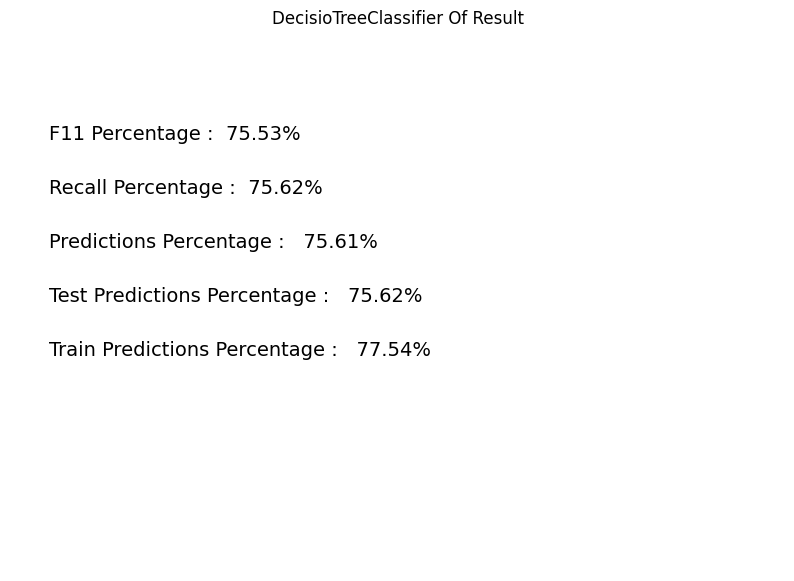

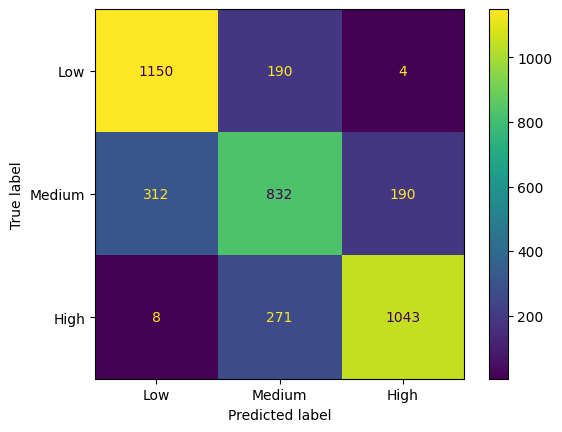


Calculating Learning Curve...


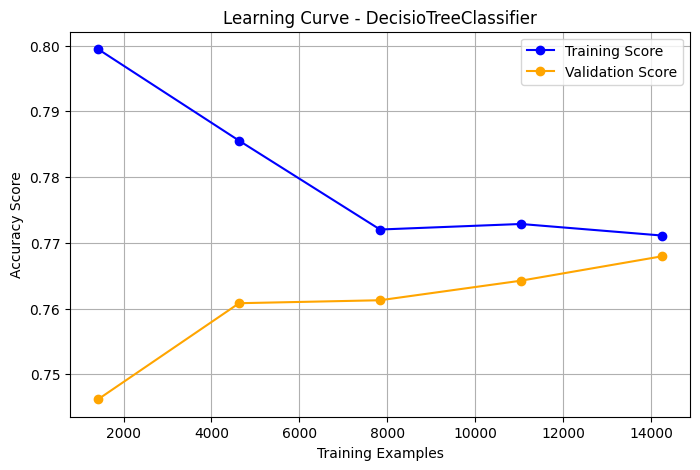

In [14]:
# Classification step using logisticregression 

time_start = time.perf_counter()

model_dtc = DecisionTreeClassifier(          
    max_depth=4,              
    min_samples_split=20,     
    min_samples_leaf=10,      
    random_state=42,      
)


model_dtc.fit(X_train_smote, y_train_smote)

train_predictions = model_dtc.predict(X_train_smote)
test_predictions = model_dtc.predict(X_valid)

# Evaluating
train_accuracy = accuracy_score(y_train_smote, train_predictions)
test_accuracy = accuracy_score(y_valid, test_predictions)

Recall = recall_score(y_valid, test_predictions, average='weighted')
Precision = precision_score(y_valid, test_predictions, average='weighted')
F11 = f1_score(y_valid, test_predictions, average='weighted')
cm = confusion_matrix(y_valid, test_predictions)

print(f"Time predict : {format(time.perf_counter() - time_start)} seconds")

plt.figure(figsize=(10,7))
plt.axis('off')
plt.title("DecisioTreeClassifier Of Result")

plt.text(0.05, 0.80, f"F11 Percentage : {F11 * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.70, f"Recall Percentage : {Recall * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.60, f"Predictions Percentage :  {Precision * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.50, f"Test Predictions Percentage :  {test_accuracy * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.40, f"Train Predictions Percentage :  {train_accuracy * 100 : .2f}%", fontsize=14, ha='left')

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "Medium", "High"]).plot()

plt.show()

# Learning Curve
print("\nCalculating Learning Curve...") 

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 5) # Menguji dari 10% hingga 100% ukuran data

X_full = np.vstack((X_train_smote, X_valid)) if hasattr(X_train_smote, 'values') else np.concatenate((X_train_smote, X_valid))
y_full = np.concatenate((y_train_smote, y_valid))

train_sizes, train_scores, test_scores = learning_curve(
    estimator=model_dtc,
    X=X_full,
    y=y_full,
    cv=cv_strategy,
    scoring='accuracy',
    train_sizes=train_sizes,
    n_jobs=-1 
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="orange", label="Validation Score")

plt.title("Learning Curve - DecisioTreeClassifier")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()


Time predict : 0.8307812999992166 seconds


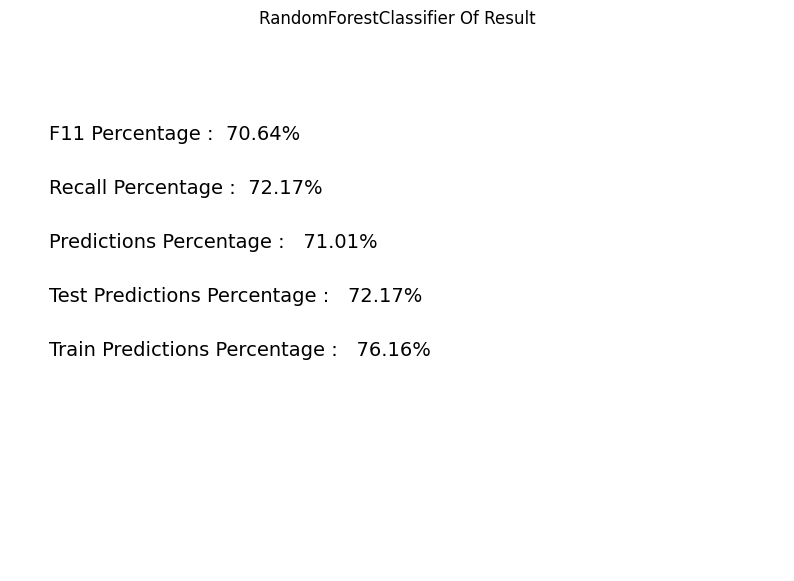

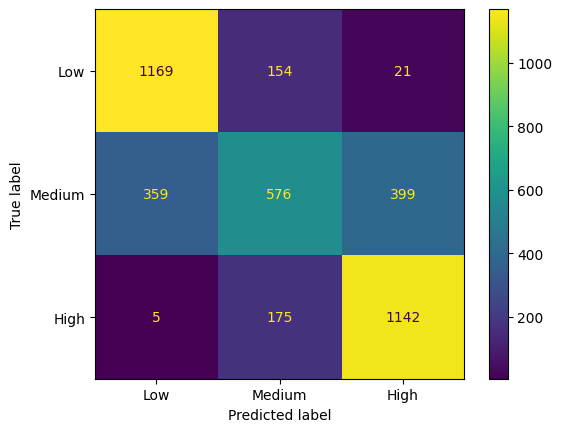


Calculating Learning Curve...


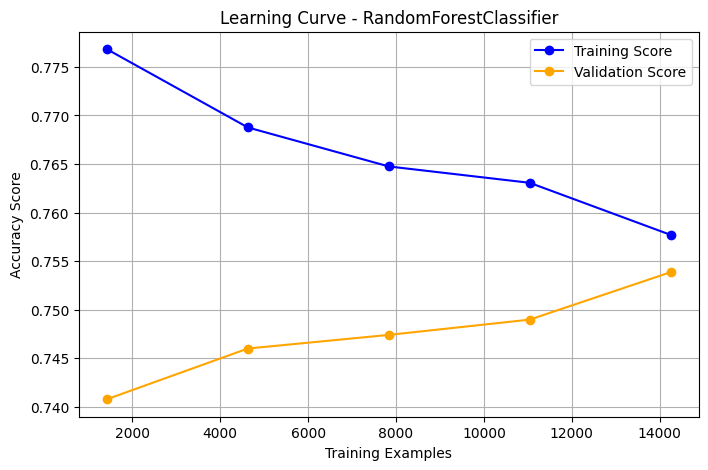

In [15]:
# Classification step using RandomForestClassifier

time_start = time.perf_counter()

model_rfc = RandomForestClassifier(    
    n_estimators=200,      
    max_depth=4,           
    min_samples_split=20,   
    min_samples_leaf=10,    
    random_state=42,
)

model_rfc.fit(X_train_smote, y_train_smote)

train_predictions = model_rfc.predict(X_train_smote)
test_predictions = model_rfc.predict(X_valid)

# Evaluating
train_accuracy = accuracy_score(y_train_smote, train_predictions)
test_accuracy = accuracy_score(y_valid, test_predictions)

Recall = recall_score(y_valid, test_predictions, average='weighted')
Precision = precision_score(y_valid, test_predictions, average='weighted')
F11 = f1_score(y_valid, test_predictions, average='weighted')
cm = confusion_matrix(y_valid, test_predictions)

print(f"Time predict : {format(time.perf_counter() - time_start)} seconds")

plt.figure(figsize=(10,7))
plt.axis('off')
plt.title("RandomForestClassifier Of Result")

plt.text(0.05, 0.80, f"F11 Percentage : {F11 * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.70, f"Recall Percentage : {Recall * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.60, f"Predictions Percentage :  {Precision * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.50, f"Test Predictions Percentage :  {test_accuracy * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.40, f"Train Predictions Percentage :  {train_accuracy * 100 : .2f}%", fontsize=14, ha='left')

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "Medium", "High"]).plot()

plt.show()

# Learning Curve
print("\nCalculating Learning Curve...") 

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 5)

X_full = np.vstack((X_train_smote, X_valid)) if hasattr(X_train_smote, 'values') else np.concatenate((X_train_smote, X_valid))
y_full = np.concatenate((y_train_smote, y_valid))

train_sizes, train_scores, test_scores = learning_curve(
    estimator=model_rfc,
    X=X_full,
    y=y_full,
    cv=cv_strategy,
    scoring='accuracy',
    train_sizes=train_sizes,
    n_jobs=-1 
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="orange", label="Validation Score")

plt.title("Learning Curve - RandomForestClassifier")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()


c:\Users\62877\miniconda3\envs\ml\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:28:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Time predict : 0.1944344999938039 seconds


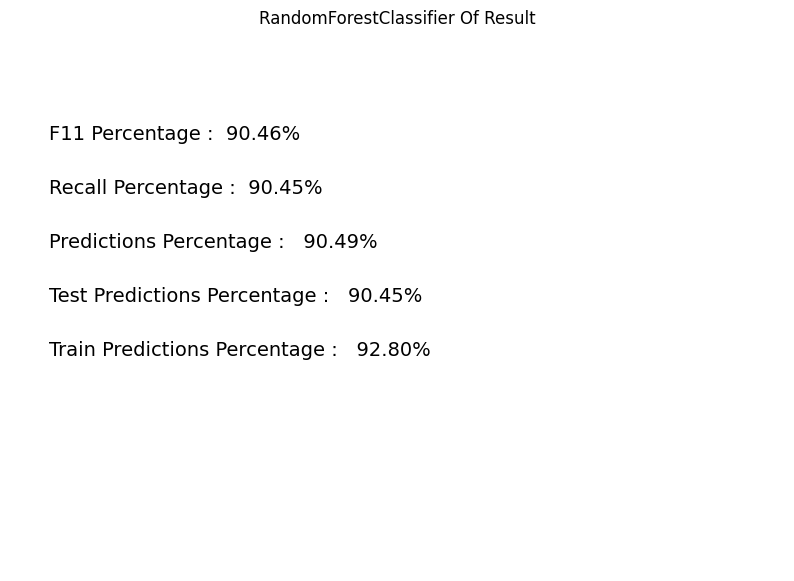

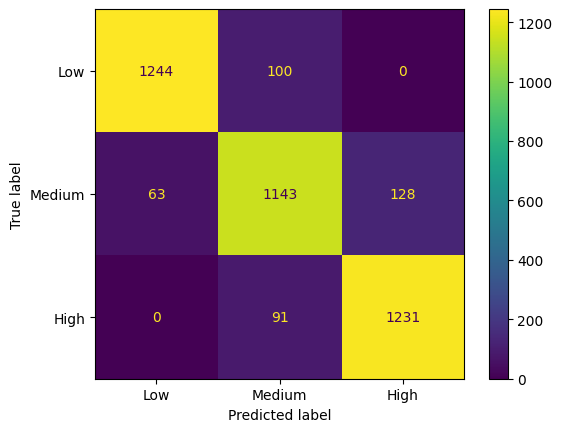


Calculating Learning Curve...


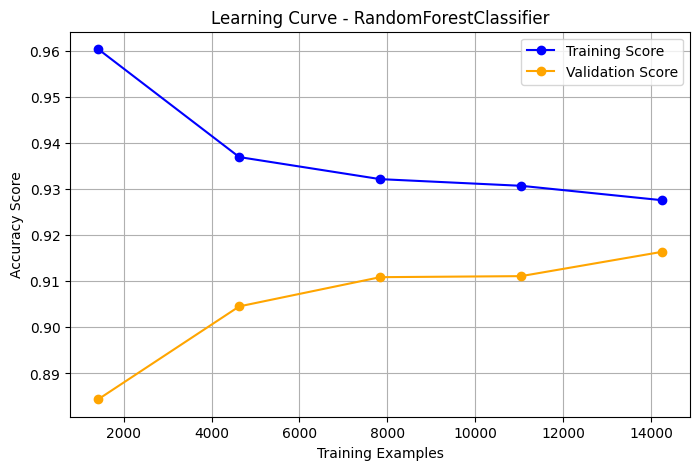

In [20]:
# Classification step using RandomForestClassifier

time_start = time.perf_counter()

model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.2,
    random_state=42,
    use_label_encoder=False,
)


model_xgb.fit(X_train_smote, y_train_smote)

train_predictions = model_xgb.predict(X_train_smote)
test_predictions = model_xgb.predict(X_valid)

# Evaluating
train_accuracy = accuracy_score(y_train_smote, train_predictions)
test_accuracy = accuracy_score(y_valid, test_predictions)

Recall = recall_score(y_valid, test_predictions, average='weighted')
Precision = precision_score(y_valid, test_predictions, average='weighted')
F11 = f1_score(y_valid, test_predictions, average='weighted')
cm = confusion_matrix(y_valid, test_predictions)

print(f"Time predict : {format(time.perf_counter() - time_start)} seconds")

plt.figure(figsize=(10,7))
plt.axis('off')
plt.title("RandomForestClassifier Of Result")

plt.text(0.05, 0.80, f"F11 Percentage : {F11 * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.70, f"Recall Percentage : {Recall * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.60, f"Predictions Percentage :  {Precision * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.50, f"Test Predictions Percentage :  {test_accuracy * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.40, f"Train Predictions Percentage :  {train_accuracy * 100 : .2f}%", fontsize=14, ha='left')

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "Medium", "High"]).plot()

plt.show()

# Learning Curve
print("\nCalculating Learning Curve...") 

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 5)

X_full = np.vstack((X_train_smote, X_valid)) if hasattr(X_train_smote, 'values') else np.concatenate((X_train_smote, X_valid))
y_full = np.concatenate((y_train_smote, y_valid))

train_sizes, train_scores, test_scores = learning_curve(
    estimator=model_xgb,
    X=X_full,
    y=y_full,
    cv=cv_strategy,
    scoring='accuracy',
    train_sizes=train_sizes,
    n_jobs=-1 
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="orange", label="Validation Score")

plt.title("Learning Curve - RandomForestClassifier")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()
